In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd
import numpy as np
import folium
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder,StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix,f1_score,classification_report

In [2]:
Colums=["A1_Score","A2_Score","A3_Score","A4_Score","A5_Score",
        "A6_Score","A7_Score","A8_Score","A9_Score","A10_Score",
        "age","gender","ethicity","jundice","austim","country_of_res",
        "used_app_before","result","age_desc","realation","class/ASD"]
df=pd.read_csv(r"C:\Users\Admin\Downloads\Autism-Adult-Data.csv",names=Colums)
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethicity,jundice,austim,country_of_res,used_app_before,result,age_desc,realation,class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2,'18 and more',?,NO


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   A1_Score         704 non-null    int64 
 1   A2_Score         704 non-null    int64 
 2   A3_Score         704 non-null    int64 
 3   A4_Score         704 non-null    int64 
 4   A5_Score         704 non-null    int64 
 5   A6_Score         704 non-null    int64 
 6   A7_Score         704 non-null    int64 
 7   A8_Score         704 non-null    int64 
 8   A9_Score         704 non-null    int64 
 9   A10_Score        704 non-null    int64 
 10  age              704 non-null    object
 11  gender           704 non-null    object
 12  ethicity         704 non-null    object
 13  jundice          704 non-null    object
 14  austim           704 non-null    object
 15  country_of_res   704 non-null    object
 16  used_app_before  704 non-null    object
 17  result           704 non-null    in

In [4]:
df.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,result
count,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000
mean,0.721591,0.453125,0.457386,0.495739,0.498580,0.284091,0.417614,0.649148,0.323864,0.573864,4.875000
std,0.448535,0.498152,0.498535,0.500337,0.500353,0.451301,0.493516,0.477576,0.468281,0.494866,2.501493
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,4.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000


In [5]:
#df=df.drop(["A1_Score","A2_Score","A3_Score","A4_Score","A5_Score","A6_Score","A7_Score","A8_Score","A9_Score","A10_Score","age_desc","used_app_before"],axis=1)	
#df.head()

In [6]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)
df

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethicity,jundice,austim,country_of_res,used_app_before,result,age_desc,realation,class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2,'18 and more',?,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
694,0,1,0,1,1,0,1,1,1,1,...,f,White-European,no,no,Russia,no,7,'18 and more',Self,YES
695,1,0,0,0,0,0,0,1,0,1,...,m,Hispanic,no,no,Mexico,no,3,'18 and more',Parent,NO
696,1,0,1,1,1,0,1,1,0,1,...,f,?,no,no,Russia,no,7,'18 and more',?,YES
697,1,0,0,1,1,0,1,0,1,1,...,m,'South Asian',no,no,Pakistan,no,6,'18 and more',Self,NO


In [7]:
df.isnull().sum()

A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethicity           0
jundice            0
austim             0
country_of_res     0
used_app_before    0
result             0
age_desc           0
realation          0
class/ASD          0
dtype: int64

In [8]:
import numpy as np


df.replace('?', np.nan, inplace=True)
df

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethicity,jundice,austim,country_of_res,used_app_before,result,age_desc,realation,class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,NaN,no,no,Egypt,no,2,'18 and more',NaN,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
694,0,1,0,1,1,0,1,1,1,1,...,f,White-European,no,no,Russia,no,7,'18 and more',Self,YES
695,1,0,0,0,0,0,0,1,0,1,...,m,Hispanic,no,no,Mexico,no,3,'18 and more',Parent,NO
696,1,0,1,1,1,0,1,1,0,1,...,f,NaN,no,no,Russia,no,7,'18 and more',NaN,YES
697,1,0,0,1,1,0,1,0,1,1,...,m,'South Asian',no,no,Pakistan,no,6,'18 and more',Self,NO


In [9]:
df.isna().sum()

A1_Score            0
A2_Score            0
A3_Score            0
A4_Score            0
A5_Score            0
A6_Score            0
A7_Score            0
A8_Score            0
A9_Score            0
A10_Score           0
age                 2
gender              0
ethicity           95
jundice             0
austim              0
country_of_res      0
used_app_before     0
result              0
age_desc            0
realation          95
class/ASD           0
dtype: int64

In [10]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df=df[df["age"]<80]
df

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethicity,jundice,austim,country_of_res,used_app_before,result,age_desc,realation,class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,NaN,no,no,Egypt,no,2,'18 and more',NaN,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
694,0,1,0,1,1,0,1,1,1,1,...,f,White-European,no,no,Russia,no,7,'18 and more',Self,YES
695,1,0,0,0,0,0,0,1,0,1,...,m,Hispanic,no,no,Mexico,no,3,'18 and more',Parent,NO
696,1,0,1,1,1,0,1,1,0,1,...,f,NaN,no,no,Russia,no,7,'18 and more',NaN,YES
697,1,0,0,1,1,0,1,0,1,1,...,m,'South Asian',no,no,Pakistan,no,6,'18 and more',Self,NO


In [11]:
df["realation"]=df["realation"].fillna(df["realation"].mode()[0])
df["ethicity"]=df["ethicity"].fillna(df["ethicity"].mode()[0])
df

C:\Users\Admin\AppData\Local\Temp\ipykernel_4808\1976095724.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["realation"]=df["realation"].fillna(df["realation"].mode()[0])
C:\Users\Admin\AppData\Local\Temp\ipykernel_4808\1976095724.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["ethicity"]=df["ethicity"].fillna(df["ethicity"].mode()[0])


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethicity,jundice,austim,country_of_res,used_app_before,result,age_desc,realation,class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,White-European,no,no,Egypt,no,2,'18 and more',Self,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
694,0,1,0,1,1,0,1,1,1,1,...,f,White-European,no,no,Russia,no,7,'18 and more',Self,YES
695,1,0,0,0,0,0,0,1,0,1,...,m,Hispanic,no,no,Mexico,no,3,'18 and more',Parent,NO
696,1,0,1,1,1,0,1,1,0,1,...,f,White-European,no,no,Russia,no,7,'18 and more',Self,YES
697,1,0,0,1,1,0,1,0,1,1,...,m,'South Asian',no,no,Pakistan,no,6,'18 and more',Self,NO


In [12]:
df.isnull().sum()

A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethicity           0
jundice            0
austim             0
country_of_res     0
used_app_before    0
result             0
age_desc           0
realation          0
class/ASD          0
dtype: int64

In [13]:
df["country_of_res"] = df["country_of_res"].astype(str).str.lower().str.replace("'", "", regex=False).str.strip()
df["ethicity"] = df["ethicity"].astype(str).str.lower().str.replace("'", "", regex=False).str.strip()
df

C:\Users\Admin\AppData\Local\Temp\ipykernel_4808\3011029431.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["country_of_res"] = df["country_of_res"].astype(str).str.lower().str.replace("'", "", regex=False).str.strip()
C:\Users\Admin\AppData\Local\Temp\ipykernel_4808\3011029431.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["ethicity"] = df["ethicity"].astype(str).str.lower().str.replace("'", "", regex=False).str.strip()


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethicity,jundice,austim,country_of_res,used_app_before,result,age_desc,realation,class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,white-european,no,no,united states,no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,latino,no,yes,brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,latino,yes,yes,spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,white-european,no,yes,united states,no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,white-european,no,no,egypt,no,2,'18 and more',Self,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
694,0,1,0,1,1,0,1,1,1,1,...,f,white-european,no,no,russia,no,7,'18 and more',Self,YES
695,1,0,0,0,0,0,0,1,0,1,...,m,hispanic,no,no,mexico,no,3,'18 and more',Parent,NO
696,1,0,1,1,1,0,1,1,0,1,...,f,white-european,no,no,russia,no,7,'18 and more',Self,YES
697,1,0,0,1,1,0,1,0,1,1,...,m,south asian,no,no,pakistan,no,6,'18 and more',Self,NO


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 696 entries, 0 to 698
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         696 non-null    int64  
 1   A2_Score         696 non-null    int64  
 2   A3_Score         696 non-null    int64  
 3   A4_Score         696 non-null    int64  
 4   A5_Score         696 non-null    int64  
 5   A6_Score         696 non-null    int64  
 6   A7_Score         696 non-null    int64  
 7   A8_Score         696 non-null    int64  
 8   A9_Score         696 non-null    int64  
 9   A10_Score        696 non-null    int64  
 10  age              696 non-null    float64
 11  gender           696 non-null    object 
 12  ethicity         696 non-null    object 
 13  jundice          696 non-null    object 
 14  austim           696 non-null    object 
 15  country_of_res   696 non-null    object 
 16  used_app_before  696 non-null    object 
 17  result           696 

In [15]:
df.isnull().sum()

A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethicity           0
jundice            0
austim             0
country_of_res     0
used_app_before    0
result             0
age_desc           0
realation          0
class/ASD          0
dtype: int64

In [16]:
df.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result
count,696.000000,696.000000,696.000000,696.000000,696.000000,696.000000,696.000000,696.000000,696.000000,696.000000,696.000000,696.000000
mean,0.721264,0.451149,0.456897,0.498563,0.497126,0.284483,0.416667,0.649425,0.324713,0.576149,29.185345,4.876437
std,0.448700,0.497966,0.498497,0.500358,0.500351,0.451492,0.493361,0.477493,0.468604,0.494523,9.686829,2.488932
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,3.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,27.000000,4.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.000000,7.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,64.000000,10.000000


In [17]:
df 


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethicity,jundice,austim,country_of_res,used_app_before,result,age_desc,realation,class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,white-european,no,no,united states,no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,latino,no,yes,brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,latino,yes,yes,spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,white-european,no,yes,united states,no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,white-european,no,no,egypt,no,2,'18 and more',Self,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
694,0,1,0,1,1,0,1,1,1,1,...,f,white-european,no,no,russia,no,7,'18 and more',Self,YES
695,1,0,0,0,0,0,0,1,0,1,...,m,hispanic,no,no,mexico,no,3,'18 and more',Parent,NO
696,1,0,1,1,1,0,1,1,0,1,...,f,white-european,no,no,russia,no,7,'18 and more',Self,YES
697,1,0,0,1,1,0,1,0,1,1,...,m,south asian,no,no,pakistan,no,6,'18 and more',Self,NO


which age affect the austim?

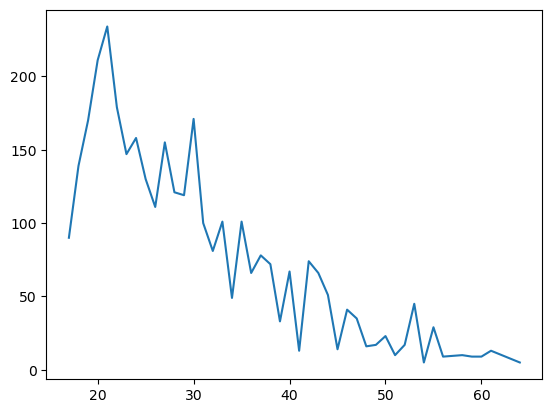

In [18]:
groups=df.groupby("age")["result"].sum()
plt.plot(groups.index,groups.values);

the age between 17 to 30 

the highest country effect autsm and thier ages?

In [19]:
fig = px.bar(df, x='country_of_res', y='result',color="age")
fig.show()

united states and their age between 17 to 30

In [20]:
fig = px.violin(df, x='realation', y='austim',color="age",
                box=True, title='realation of austim')
fig.show()

In [21]:
fig = px.bar(df, x='realation', y='jundice',color="age",
             barmode='stack', title='ethicity  by austim')
fig.show()

In [22]:
fig = px.bar(df, x='ethicity', y='austim',color="age",
             barmode='stack', title='ethicity  by austim')
fig.show()

which heighest ethicity has jundice

In [23]:
fig = px.bar(df, x='ethicity', y='jundice',color="age",
             barmode='stack', title='ethicity  by jundice')
fig.show()

white-european heighest jundice

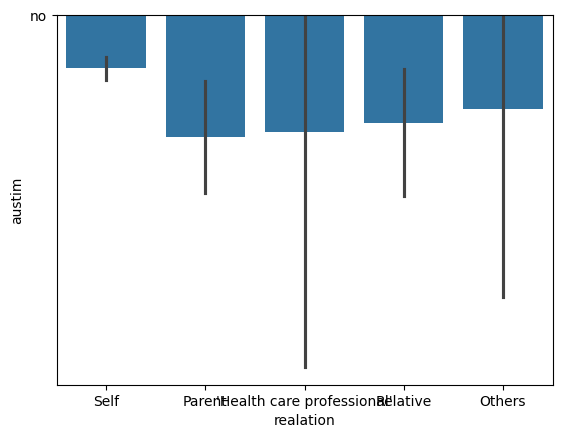

In [24]:
sns.barplot(x="realation",y="austim",data=df);

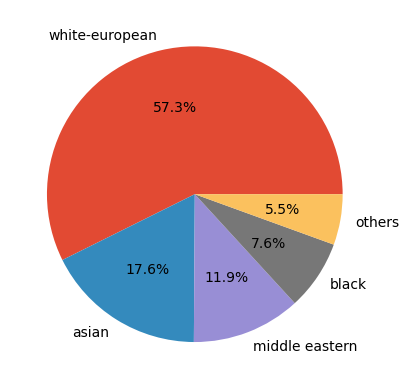

In [25]:
top_ethicity = df.groupby('ethicity')['result'].sum()
top_ethicity=top_ethicity.sort_values(ascending=False)
top_ethicity=top_ethicity.head(5)
plt.style.use("ggplot")
plt.pie(top_ethicity.values, labels=top_ethicity.index, autopct='%1.1f%%');

<Axes: xlabel='class/ASD', ylabel='count'>

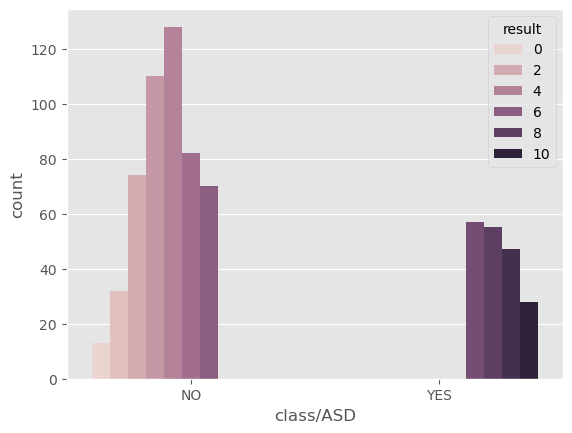

In [26]:
sns.countplot(x='class/ASD', hue='result', data=df)

<Axes: xlabel='jundice', ylabel='count'>

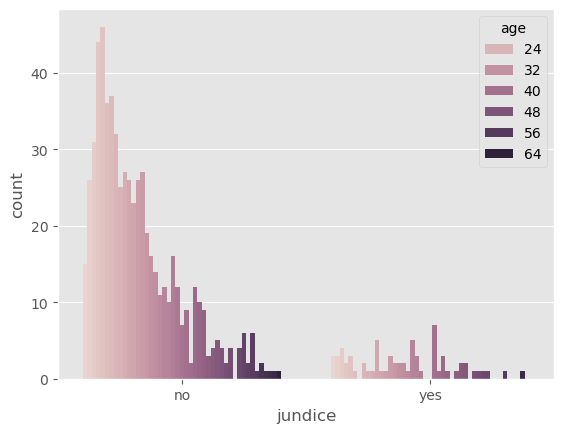

In [27]:
sns.countplot(x='jundice', hue='age', data=df)

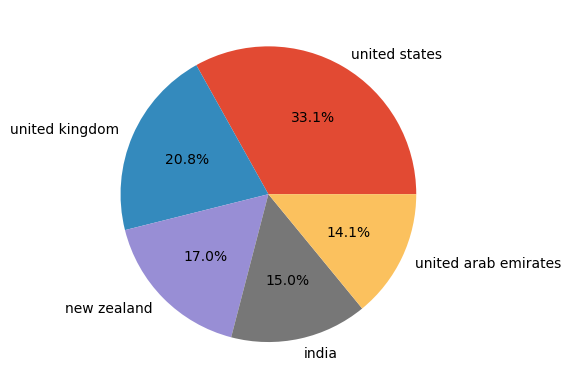

In [28]:
top_country_of_res = df.groupby('country_of_res')['result'].sum()
top_country_of_res=top_country_of_res.sort_values(ascending=False)
top_country_of_res=top_country_of_res.head(5)
plt.style.use("ggplot")
plt.pie(top_country_of_res.values, labels=top_country_of_res.index, autopct='%1.1f%%');

which realation highest affect in class/asd?

<Axes: xlabel='realation', ylabel='count'>

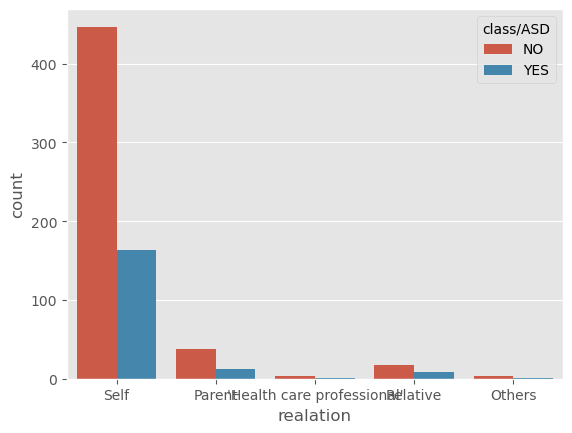

In [29]:
sns.countplot(data=df,x="realation",hue='class/ASD')

parent most effect in class/asd

which gender affect austim?

<Axes: xlabel='gender', ylabel='count'>

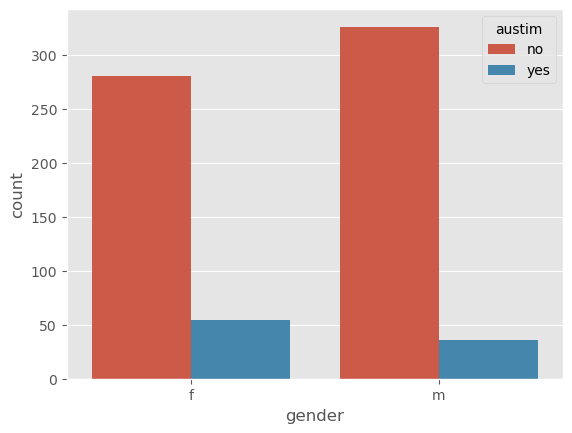

In [30]:
sns.countplot(data=df,x="gender",hue='austim')

famale affect austim

In [31]:
#m =folium.Map(location=(30.044 , 31.2357),zoom_start=6)
#Iraqi_loc=[33.3333 , 44.4333]
#united_states_loc=[37.843322, -105.948203 ]
#folium.Marker(Iraqi_loc,popup="Iraqi").add_to(m)
#folium.Marker(united_states_loc,popup="united_states").add_to(m)
#folium.PolyLine([Iraqi_loc,united_states_loc]).add_to(m)
#m

In [32]:
X = df.drop("class/ASD", axis=1) 
y = df['class/ASD'] 

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [34]:
cat_cols = ["gender","ethicity","jundice","austim","country_of_res","used_app_before","age_desc","realation"]
encoder =  OrdinalEncoder(
 handle_unknown='use_encoded_value',
 unknown_value=-1
)
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

In [35]:
en = LabelEncoder()
df["class/ASD"] = en.fit_transform(df["class/ASD"])

C:\Users\Admin\AppData\Local\Temp\ipykernel_4808\699108106.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [36]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)


In [37]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)
y_pred_train = log_model.predict(X_train)
y_pred_test = log_model.predict(X_test)

In [38]:
print(classification_report(y_pred_train,y_train)),
print(classification_report(y_pred_test,y_test))

              precision    recall  f1-score   support

          NO       1.00      1.00      1.00       407
         YES       1.00      1.00      1.00       149

    accuracy                           1.00       556
   macro avg       1.00      1.00      1.00       556
weighted avg       1.00      1.00      1.00       556

              precision    recall  f1-score   support

          NO       1.00      1.00      1.00       102
         YES       1.00      1.00      1.00        38

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



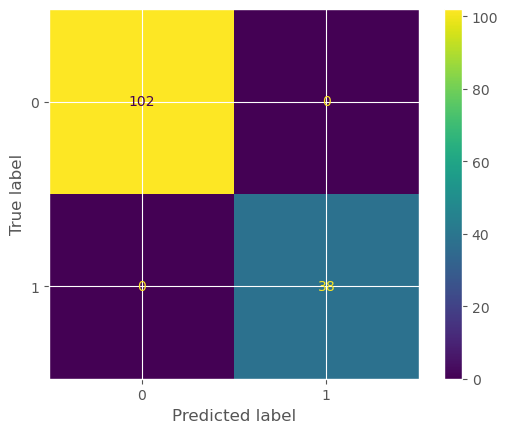

In [39]:
cm=confusion_matrix(y_test,y_pred_test)
ConfusionMatrixDisplay(cm).plot()

In [40]:
dmodel = DecisionTreeClassifier()
dmodel.fit(X_train, y_train)

y_pred_train = dmodel.predict(X_train)
y_pred_test = dmodel.predict(X_test)

In [41]:
print(classification_report(y_pred_train,y_train)),
print(classification_report(y_pred_test,y_test))

              precision    recall  f1-score   support

          NO       1.00      1.00      1.00       407
         YES       1.00      1.00      1.00       149

    accuracy                           1.00       556
   macro avg       1.00      1.00      1.00       556
weighted avg       1.00      1.00      1.00       556

              precision    recall  f1-score   support

          NO       1.00      1.00      1.00       102
         YES       1.00      1.00      1.00        38

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



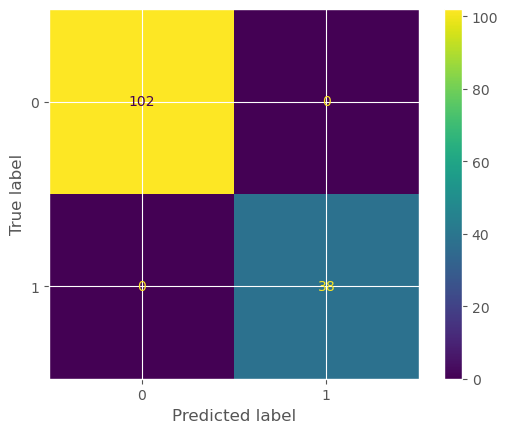

In [42]:
cm=confusion_matrix(y_test,y_pred_test)
ConfusionMatrixDisplay(cm).plot()

In [43]:
rmodel = RandomForestClassifier()
rmodel.fit(X_train, y_train)

y_pred_train = rmodel.predict(X_train)
y_pred_test = rmodel.predict(X_test)

In [44]:
print(classification_report(y_pred_train,y_train)),
print(classification_report(y_pred_test,y_test))

              precision    recall  f1-score   support

          NO       1.00      1.00      1.00       407
         YES       1.00      1.00      1.00       149

    accuracy                           1.00       556
   macro avg       1.00      1.00      1.00       556
weighted avg       1.00      1.00      1.00       556

              precision    recall  f1-score   support

          NO       1.00      1.00      1.00       102
         YES       1.00      1.00      1.00        38

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



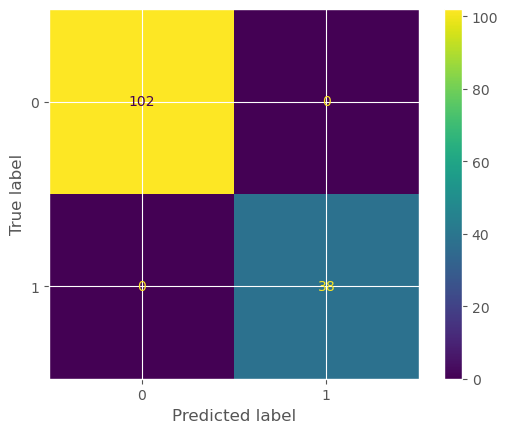

In [45]:
cm=confusion_matrix(y_test,y_pred_test)
ConfusionMatrixDisplay(cm).plot()